# Training history visualization

Loads `config.json`, `history.json` and `history_val.json` from a run folder under `trained_models/<timestamp>/` (see `main.py`) and plots train vs. validation curves.

**Note on the x-axis:** each history key is only appended on the epochs where it was actually computed (e.g. `mse_phi` during the phi-stage epochs, `res_1..res_3` only for the occasional full-residual batches before `PHI_EPOCHS`, `res_4`/`res_sum` on every flow epoch). The lists are therefore not all the same length and the x-axis below is the **index within that series** (the n-th time the metric was logged), not the raw epoch number.

In [92]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np

# --- validated categorical palette (dataviz skill), fixed order, never cycled ---
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'
SURFACE = '#fcfcfb'

METRIC_COLORS = {
    'res_1':   '#2a78d6',  # blue
    'res_2':   '#1baf7a',  # aqua
    'res_3':   '#eda100',  # yellow
    'res_4':   '#008300',  # green
    'res_sum': '#4a3aa7',  # violet
    'mse_phi': '#e34948',  # red
    'lr_flow': '#e87ba4',  # magenta
    'lr_phi':  '#eb6834',  # orange
}

plt.rcParams.update({
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.labelcolor': INK_SECONDARY,
    'text.color': INK_PRIMARY,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'grid.color': GRIDLINE,
    'axes.grid': True,
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'lines.linewidth': 1.6,
    'font.size': 11,
})

## Pick a run

Leave `RUN_DIR = None` to auto-pick the most recent folder under `trained_models/` (names sort chronologically since they are `%Y-%m-%d_%H-%M-%S`).

In [ ]:
TRAINED_MODELS_DIR = 'trained_models'
RUN_DIR = 'trained_models/2026-08-14_08-23-19'  # e.g. 'trained_models/2026-07-04_12-00-00' to pin a specific run

if RUN_DIR is None:
    if not os.path.isdir(TRAINED_MODELS_DIR):
        raise FileNotFoundError(
            f"'{TRAINED_MODELS_DIR}/' does not exist. Run main.py first, or set RUN_DIR explicitly."
        )
    runs = sorted(
        d for d in os.listdir(TRAINED_MODELS_DIR)
        if os.path.isdir(os.path.join(TRAINED_MODELS_DIR, d))
    )
    if not runs:
        raise FileNotFoundError(
            f"No run folders found under '{TRAINED_MODELS_DIR}/'. Run main.py first, "
            "or set RUN_DIR explicitly."
        )
    RUN_DIR = os.path.join(TRAINED_MODELS_DIR, runs[-1])

print(f'Using run: {RUN_DIR}')

Using run: trained_models\2026-08-14_13-08-02


In [94]:
def load_json(path, default=None):
    if not os.path.exists(path):
        print(f'(missing: {path})')
        return default
    with open(path, 'r') as fp:
        return json.load(fp)

config = load_json(os.path.join(RUN_DIR, 'config.json'), default={})
history = load_json(os.path.join(RUN_DIR, 'history.json'), default={})
history_val = load_json(os.path.join(RUN_DIR, 'history_val.json'), default={})

RES_KEYS = ['res_1', 'res_2', 'res_3', 'res_4', 'res_sum']
LR_KEYS = ['lr_flow', 'lr_phi']

## Run config

In [95]:
if config:
    width = max((len(k) for k in config), default=0)
    for k, v in config.items():
        print(f'{k:<{width}}  {v}')
else:
    print('No config.json found for this run.')

LOCAL             True
FULL_TRAIN        False
USE_CLEARML       False
USE_EMB           True
USE_CLS_TOKEN     True
ACT               wave
INTERIOR_SIZE     500
WALLS_SIZE        250
INLET_SIZE        100
OUTLET_SIZE       100
OUTERIOR_SIZE     250
Q                 1.5e-06
S                 2e-06
PHI_EPOCHS        15000
EPOCHS            20000
DIV_POR           5
VAL_EVERY         50
B                 10
RESUME_PINN       False
RESUME_TASK       2d26aafa8d0445f7a1ab3040b1dca91b
GEN_POINTS        False
AUGMENT_ROTATION  True
AUGMENT_PERMUTE   True
AUGMENT_REFLECT   True
DATASET_PATH      SimVascDataset
SPLIT             {'train': ['0096_A_AO_COA', '0099_A_AO_COA'], 'val': ['0118_H_PULM_WS'], 'test': ['0122_H_PULM_ALGS']}


## Plot helpers

In [96]:
def plot_metric(ax, key, log_scale=True):
    color = METRIC_COLORS.get(key, INK_SECONDARY)
    train_vals = history.get(key, [])
    val_vals = history_val.get(key, [])

    has_data = False
    if train_vals:
        ax.plot(np.arange(len(train_vals)), train_vals, color=color, linestyle='-',
                label=f'{key} (train)')
        has_data = True
    if val_vals:
        ax.plot(np.arange(len(val_vals)), val_vals, color=color, linestyle='--',
                marker='o', markersize=3, label=f'{key} (val)')
        has_data = True

    ax.set_title(key, color=INK_PRIMARY, fontsize=11)
    ax.set_xlabel('logged index')

    if not has_data:
        ax.text(0.5, 0.5, 'no data', transform=ax.transAxes, ha='center', va='center',
                color=INK_MUTED)
        return

    if log_scale and all(v > 0 for v in train_vals + val_vals):
        ax.set_yscale('log')
    ax.legend(frameon=False, fontsize=9)


def plot_group(keys, log_scale=True, suptitle=None):
    n = len(keys)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows), squeeze=False)
    for idx, key in enumerate(keys):
        plot_metric(axes[idx // ncols][idx % ncols], key, log_scale=log_scale)
    for idx in range(n, nrows * ncols):
        axes[idx // ncols][idx % ncols].axis('off')
    if suptitle:
        fig.suptitle(suptitle, color=INK_PRIMARY, fontsize=13)
    fig.tight_layout()
    return fig

## Phi-stage loss

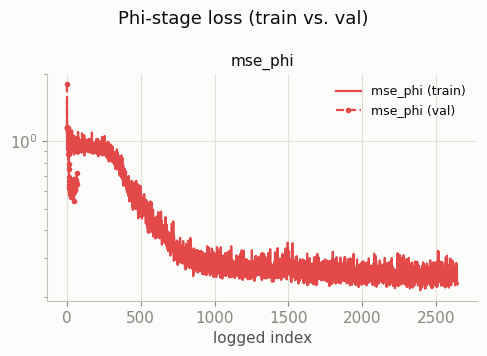

In [97]:
plot_group(['mse_phi'], log_scale=True, suptitle='Phi-stage loss (train vs. val)')
plt.show()

## Flow-stage residuals

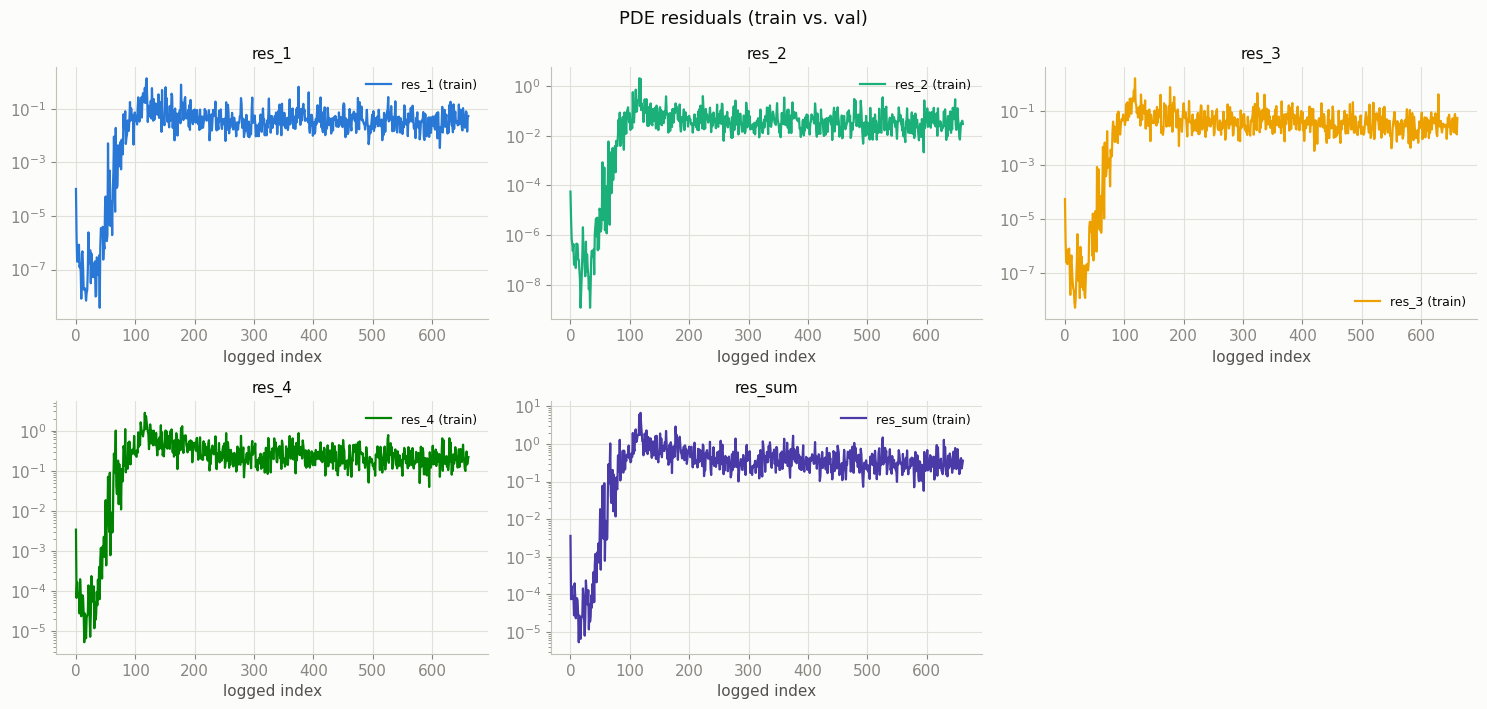

In [98]:
plot_group(RES_KEYS, log_scale=True, suptitle='PDE residuals (train vs. val)')
plt.show()

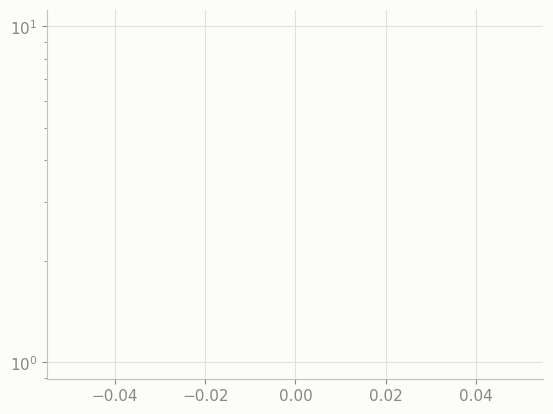

In [99]:

plt.plot(history['res_4'][3000::])
plt.yscale('log')

In [100]:
len(history['res_4'])

662

## Learning rates

Train-only (no LR schedule is stepped during validation). Kept on separate axes rather than a dual-axis plot since `lr_flow` and `lr_phi` follow independent schedules.

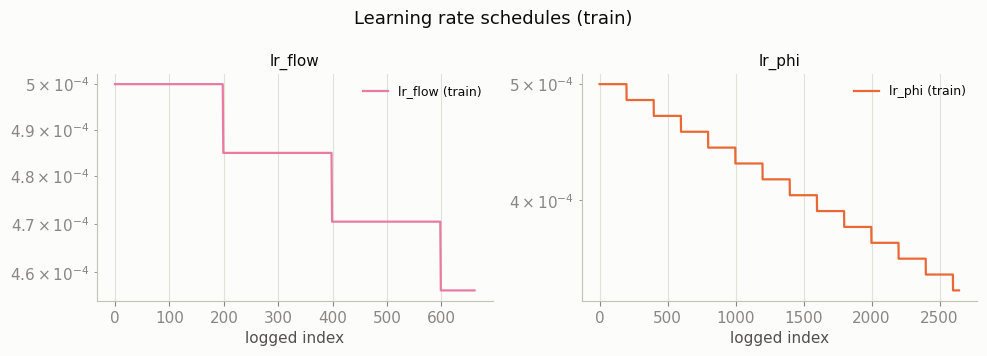

In [101]:
plot_group(LR_KEYS, log_scale=True, suptitle='Learning rate schedules (train)')
plt.show()

## Summary: last & best values

In [102]:
def summarize(key):
    row = {'metric': key}
    for split_name, split_hist in [('train', history), ('val', history_val)]:
        vals = split_hist.get(key, [])
        if vals:
            best_idx = int(np.argmin(vals))
            row[f'{split_name}_last'] = vals[-1]
            row[f'{split_name}_best'] = vals[best_idx]
            row[f'{split_name}_best_idx'] = best_idx
        else:
            row[f'{split_name}_last'] = None
            row[f'{split_name}_best'] = None
            row[f'{split_name}_best_idx'] = None
    return row

rows = [summarize(k) for k in RES_KEYS + ['mse_phi']]

header = ['metric', 'train_last', 'train_best', 'train_best_idx', 'val_last', 'val_best', 'val_best_idx']
col_w = {h: max(len(h), *(len(str(r[h])) for r in rows)) for h in header}
print('  '.join(h.ljust(col_w[h]) for h in header))
for r in rows:
    print('  '.join(str(r[h]).ljust(col_w[h]) for h in header))

metric   train_last            train_best              train_best_idx  val_last            val_best           val_best_idx
res_1    0.05318602112432321   3.7433302198704626e-09  40              None                None               None        
res_2    0.029798659030348063  1.203183959871031e-09   33              None                None               None        
res_3    0.05396294345458349   5.068119849719703e-09   17              None                None               None        
res_4    0.21978105107943216   5.231947397987824e-06   14              None                None               None        
res_sum  0.3567286746886869    5.377618389553381e-06   14              None                None               None        
mse_phi  0.2310607781012853    0.2149845560391744      2392            0.6442782878875732  0.540503978729248  49          


In [103]:
import copy
import torch
from torch import nn

def get_clones(module, N):
    return nn.ModuleList([copy.deepcopy(module) for i in range(N)])

def get_act():
    return WaveAct()

class WaveAct(nn.Module):
    def __init__(self):
        super(WaveAct, self).__init__() 
        self.w1 = nn.Parameter(torch.ones(1), requires_grad=True)
        self.w2 = nn.Parameter(torch.ones(1), requires_grad=True)

    def forward(self, x):
        return self.w1 * torch.sin(x) + self.w2 * torch.cos(x)

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=256):
        super(FeedForward, self).__init__() 
        self.linear = nn.Sequential(*[
            nn.Linear(d_model, d_ff),
            get_act(),
            nn.Linear(d_ff, d_ff),
            get_act(),
            nn.Linear(d_ff, d_model)
        ])

    def forward(self, x):
        return self.linear(x)
    

class EncoderLayer(nn.Module):
    def __init__(self, d_model, heads):
        super(EncoderLayer, self).__init__()

        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=heads, batch_first=True)
        self.ff = FeedForward(d_model)
        self.act1 = get_act()
        self.act2 = get_act()
        
    def forward(self, x):
        x2 = self.act1(x)
        x = x + self.attn(x2,x2,x2)[0]
        x2 = self.act2(x)
        x = x + self.ff(x2)
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, heads):
        super(DecoderLayer, self).__init__()

        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=heads, batch_first=True)
        self.ff = FeedForward(d_model)
        self.act1 = get_act()
        self.act2 = get_act()

    def forward(self, x, e_outputs): 
        x2 = self.act1(x)
        x = x + self.attn(x2, e_outputs, e_outputs)[0]
        x2 = self.act2(x)
        x = x + self.ff(x2)
        return x


class Encoder(nn.Module):
    def __init__(self, d_model, N, heads):
        super(Encoder, self).__init__()
        self.N = N
        self.layers = get_clones(EncoderLayer(d_model, heads), N)
        self.act = get_act()

    def forward(self, x):
        for i in range(self.N):
            x = self.layers[i](x)
        return self.act(x)


class Decoder(nn.Module):
    def __init__(self, d_model, N, heads):
        super(Decoder, self).__init__()
        self.N = N
        self.layers = get_clones(DecoderLayer(d_model, heads), N)
        self.act = get_act()
        
    def forward(self, x, e_outputs):
        for i in range(self.N):
            x = self.layers[i](x, e_outputs)
        return self.act(x)

class GAPinn(nn.Module):
    def __init__(self, d_hidden_phi=64, d_hidden_v=256, d_model=64, N=4, heads=8):
        super(GAPinn, self).__init__()

        self.embedding = nn.Embedding(5, d_model)

        self.linear_emb = nn.Linear(9, d_model)

        self.encoder = Encoder(d_model, N, heads)
        self.decoder_phi = Decoder(d_model, N, heads)
        # self.decoder_flow = Decoder(d_model, N, heads)

        self.linear_out_phi = nn.Sequential(*[
            nn.Linear(d_model, d_hidden_phi),
            get_act(),
            nn.Linear(d_hidden_phi, d_hidden_phi),
            get_act(),
            nn.Linear(d_hidden_phi, 2)
        ])

        self.linear_out_flow = nn.Sequential(*[
            nn.Linear(d_model, d_hidden_v),
            get_act(),
            nn.Linear(d_hidden_v, d_hidden_v),
            get_act(),
            nn.Linear(d_hidden_v, d_hidden_v),
            get_act(),
            nn.Linear(d_hidden_v, d_hidden_v),
            get_act(),
            nn.Linear(d_hidden_v, d_hidden_v),
            get_act(),
            nn.Linear(d_hidden_v, d_hidden_v),
            get_act(),
            nn.Linear(d_hidden_v, d_hidden_v),
            get_act(),
            nn.Linear(d_hidden_v, d_hidden_v),
            get_act(),
            nn.Linear(d_hidden_v, d_hidden_v),
            get_act(),
            nn.Linear(d_hidden_v, d_hidden_v),
            get_act(),
            nn.Linear(d_hidden_v, 4)
        ])


    def forward(self, x, out, norm_in, norm_out, center_out, l, s, v_mean, x_label, pinn=False):
        if pinn:
            x_grad = x * 2 * l
            # x_grad = x
            x_grad.requires_grad_(True)
            x_proj_enc = self.linear_emb(torch.cat((x_grad.clone().detach() / l / 2, out.unsqueeze(1).repeat(1, x.shape[1], 1)), -1))                 # (B, N, d_model)
            if USE_EMB:
                label_emb = self.embedding(x_label)        # (B, N, d_model)
                x_proj_enc = x_proj_enc + label_emb
            
            x_proj_dec = self.linear_emb(torch.cat((x_grad / l / 2, out.unsqueeze(1).repeat(1, x.shape[1], 1)), -1))                 # (B, N, d_model)
            # x_proj_enc = self.linear_emb(torch.cat((x_grad.clone().detach(), out.unsqueeze(1).repeat(1, x.shape[1], 1)), -1))                 # (B, N, d_model)
            # x_proj_dec = self.linear_emb(torch.cat((x_grad, out.unsqueeze(1).repeat(1, x.shape[1], 1)), -1))                 # (B, N, d_model)
        else:
            x_grad = None
            x_proj_enc = x_proj_dec = self.linear_emb(torch.cat((x, out.unsqueeze(1).repeat(1, x.shape[1], 1)), -1))
            if USE_EMB:
                label_emb = self.embedding(x_label)        # (B, N, d_model)
                x_proj_enc = x_proj_enc + label_emb
            

        e_outputs = self.encoder(x_proj_enc)

        d_output_phi = self.decoder_phi(x_proj_dec, e_outputs)
        d_output_flow = self.decoder_phi(x_proj_dec[:, :_BND_END], e_outputs[:, :_BND_END])

        phi_pred = self.linear_out_phi(d_output_phi)

        pred = self.linear_out_flow(d_output_flow)

        v = pred[..., :3]
        p = pred[..., 3:]

        v = (v * phi_pred[:, :_BND_END, 1:2]
                  + phi_pred[:, :_BND_END, 0:1] * norm_in[:, :_BND_END] * ((1 / v_mean[:, :_BND_END])*((Q * (s[:, :_BND_END] / S)) / s[:, :_BND_END])))      # (B, _BND_END, 3)

        signed_dist = ((x[:, :_BND_END] - center_out[:, :_BND_END])
                       * norm_out[:, :_BND_END]).sum(-1, keepdim=True)
        
        p = p * signed_dist * 10                       # (B, _BND_END, 1)

        return None, phi_pred, v[..., 0:1], v[..., 1:2], v[..., 2:3], p, x_grad
    

ga_pinn = GAPinn().cuda()

In [104]:
ga_pinn.linear_out_flow.reset_parameters()

AttributeError: 'Sequential' object has no attribute 'reset_parameters'

In [ ]:
@torch.no_grad()
def reset_weights(m):
    """Resets weights to PyTorch defaults."""
    if hasattr(m, 'reset_parameters'):
        m.reset_parameters()

ga_pinn.linear_out_flow = ga_pinn.linear_out_flow.apply(reset_weights)

In [ ]:
ga_pinn.linear_out_flow[0]._parameters['weight']